## Kernel PCA step by step

## 1. Data generation

Text(0.5, 1.0, 'Original data')

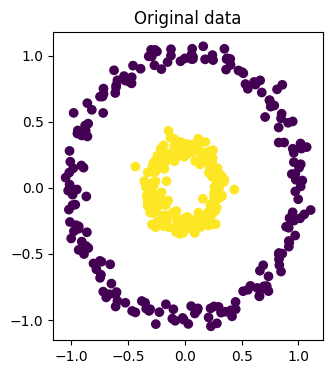

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
import numpy as np
from scipy.linalg import eigh

# Generate the dataset
X, y = make_circles(n_samples=400, factor=.3, noise=.05)

# Original data plot
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')

## 2. Kernel definition (RBF)

In [ ]:
def rbf_kernel(x1, x2, gamma=0.1):
    distance = np.linalg.norm(x1 - x2) ** 2
    return np.exp(-gamma * distance)

# Create the kernel matrix
n_samples = X.shape[0]
K = np.zeros((n_samples, n_samples))
for i in range(n_samples):
    for j in range(n_samples):
        K[i, j] = rbf_kernel(X_centered[i], X_centered[j])


## 3. Build the kernel (Gram) matrix

In [ ]:
K = np.zeros((n_samples, n_samples))
for i in range(n_samples):
    for j in range(n_samples):
        K[i, j] = rbf_kernel(X[i], X[j], gamma=0.1)


## 4. Center the kernel matrix (CRITICAL)

In [ ]:
one_n = np.ones((n_samples, n_samples)) / n_samples
K_centered = K - one_n @ K - K @ one_n + one_n @ K @ one_n


## 5. Eigen-decomposition

In [ ]:
eigenvalues, eigenvectors = eigh(K_centered)
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]


## 6. Normalize eigenvectors

In [ ]:
X_kpca = eigenvectors[:, 0] / np.sqrt(eigenvalues[0])

## 7. Visualization

In [ ]:
plt.scatter(X_kpca, np.zeros_like(X_kpca), c=y)
plt.title("Correct Kernel PCA (1D)")
plt.show()
